In [2]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from PIL import Image

In [3]:
DATASET_PATH = r"D:/PROJECTS/OTHERS/PetDx (New)/Github (Dev)/Disease_Dataset"
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10
MODEL_SAVE_PATH = "petdx_mobilenetv2.h5"

In [4]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

NUM_CLASSES = len(train_data.class_indices)
class_names = list(train_data.class_indices.keys())

print("Classes:", class_names)

Found 4023 images belonging to 10 classes.
Found 1001 images belonging to 10 classes.
Classes: ['Demodicosis_dog', 'Dermatitis_dog', 'Flea_Allergy_cat', 'Fungal_infections_dog', 'Healthy_cat', 'Healthy_dog', 'Hypersensitivity_dog', 'Ringworm_cat', 'Ringworm_dog', 'Scabies_cat']


In [5]:
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

cnn_model = Model(inputs=base_model.input, outputs=output)

cnn_model.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [6]:
history = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS
)

Epoch 1/10


126/126 [==============================] - 249s 2s/step - loss: 1.0901 - accuracy: 0.6537 - val_loss: 1.4083 - val_accuracy: 0.5514
Epoch 2/10
126/126 [==============================] - 100s 794ms/step - loss: 0.5800 - accuracy: 0.8128 - val_loss: 1.4449 - val_accuracy: 0.5664
Epoch 3/10
126/126 [==============================] - 101s 798ms/step - loss: 0.4400 - accuracy: 0.8563 - val_loss: 1.4152 - val_accuracy: 0.5734
Epoch 4/10
126/126 [==============================] - 100s 794ms/step - loss: 0.3731 - accuracy: 0.8767 - val_loss: 1.4221 - val_accuracy: 0.5894
Epoch 5/10
126/126 [==============================] - 99s 784ms/step - loss: 0.3137 - accuracy: 0.8924 - val_loss: 1.5484 - val_accuracy: 0.5904
Epoch 6/10
126/126 [==============================] - 100s 790ms/step - loss: 0.2448 - accuracy: 0.9244 - val_loss: 1.4674 - val_accuracy: 0.5844
Epoch 7/10
126/126 [==============================] - 110s 870ms/step - loss: 0.2179 - accuracy: 0.9269 - val_loss: 1.6043 - v

In [7]:
val_loss, val_acc = cnn_model.evaluate(val_data)
print(f"\nValidation Accuracy: {val_acc:.4f}")

32/32 [==============================] - 9s 284ms/step - loss: 1.8111 - accuracy: 0.5744

Validation Accuracy: 0.5744


In [8]:
cnn_model.save(MODEL_SAVE_PATH)
print(f"Model saved to: {MODEL_SAVE_PATH}")

C:\Users\MCS\AppData\Roaming\Python\Python311\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Model saved to: petdx_mobilenetv2.h5


In [9]:
import json

# Save class labels
labels_path = "class_labels.json"

with open(labels_path, "w") as f:
    json.dump(class_names, f)

print(f"Class labels saved to: {labels_path}")

Class labels saved to: class_labels.json


In [10]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    max_val = tf.math.reduce_max(heatmap)
    if max_val == 0:
        return np.zeros((heatmap.shape[0], heatmap.shape[1]))

    heatmap = tf.maximum(heatmap, 0) / max_val
    return heatmap.numpy()

def predict_and_explain(img_path, model, class_names):
    # Load image for model
    img = tf.keras.preprocessing.image.load_img(
        img_path, target_size=(IMG_SIZE, IMG_SIZE)
    )
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    # Predict
    preds = model.predict(img_array, verbose=0)
    pred_class = np.argmax(preds[0])
    confidence = float(np.max(preds[0]) * 100)
    disease_name = class_names[pred_class]

    print(f"\nPrediction: {disease_name}")
    print(f"Confidence: {confidence:.2f}%")

    # Grad-CAM
    last_conv_layer_name = "Conv_1"
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

    # Original image with OpenCV
    original_img = cv2.imread(img_path)
    if original_img is None:
        print("Error: Could not read image with OpenCV.")
        return

    original_img = cv2.resize(original_img, (IMG_SIZE, IMG_SIZE))

    heatmap = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = cv2.addWeighted(original_img, 0.6, heatmap, 0.4, 0)

    cv2.imwrite("gradcam_output.jpg", superimposed_img)

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 3, 1)
    plt.title("Original")
    plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title("Heatmap")
    plt.imshow(cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title(f"{disease_name}\n{confidence:.2f}%")
    plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [11]:
def test_single_image(img_path, model, class_names):
    img = Image.open(img_path).convert("RGB")
    img = img.resize((IMG_SIZE, IMG_SIZE))

    img_array = np.array(img, dtype=np.float32)
    img_array = np.expand_dims(img_array, axis=0)

    img_array = preprocess_input(img_array)

    prediction = model.predict(img_array, verbose=0)[0]

    pred_index = np.argmax(prediction)
    pred_label = class_names[pred_index]
    confidence = prediction[pred_index] * 100

    print(f"\nImage: {img_path}")
    print(f"Predicted class: {pred_label}")
    print(f"Confidence: {confidence:.2f}%")
    print("All class probabilities:")

    for i, prob in enumerate(prediction):
        print(f"  {class_names[i]}: {prob * 100:.2f}%")

Testing: D:\PROJECTS\OTHERS\PetDx (New)\Github (Dev)\Disease_Dataset\Demodicosis_dog\1-1-_jpg.rf.eebf0e87892957114c91ca6a3ced8e50.jpg

Image: D:\PROJECTS\OTHERS\PetDx (New)\Github (Dev)\Disease_Dataset\Demodicosis_dog\1-1-_jpg.rf.eebf0e87892957114c91ca6a3ced8e50.jpg
Predicted class: Demodicosis_dog
Confidence: 98.16%
All class probabilities:
  Demodicosis_dog: 98.16%
  Dermatitis_dog: 0.04%
  Flea_Allergy_cat: 0.01%
  Fungal_infections_dog: 1.33%
  Healthy_cat: 0.00%
  Healthy_dog: 0.33%
  Hypersensitivity_dog: 0.02%
  Ringworm_cat: 0.00%
  Ringworm_dog: 0.05%
  Scabies_cat: 0.06%

Prediction: Demodicosis_dog
Confidence: 99.34%


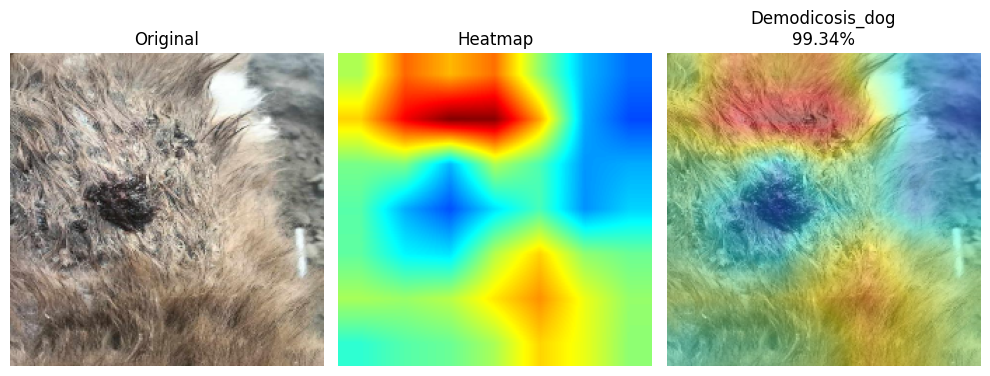

In [13]:
folder = Path(r"D:/PROJECTS/OTHERS/PetDx (New)/Github (Dev)/Disease_Dataset/Demodicosis_dog")

image_files = list(folder.glob("*.JPG")) + list(folder.glob("*.jpg")) + list(folder.glob("*.jpeg")) + list(folder.glob("*.JPEG"))

if not image_files:
    print("No image files found in the folder.")
else:
    test_image_path = str(image_files[0])
    print("Testing:", test_image_path)

    test_single_image(test_image_path, cnn_model, class_names)

    # Optional: Grad-CAM explanation
    predict_and_explain(test_image_path, cnn_model, class_names)

In [14]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [15]:
# Get true labels
y_true = val_data.classes

# Predict
y_pred_probs = cnn_model.predict(val_data, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

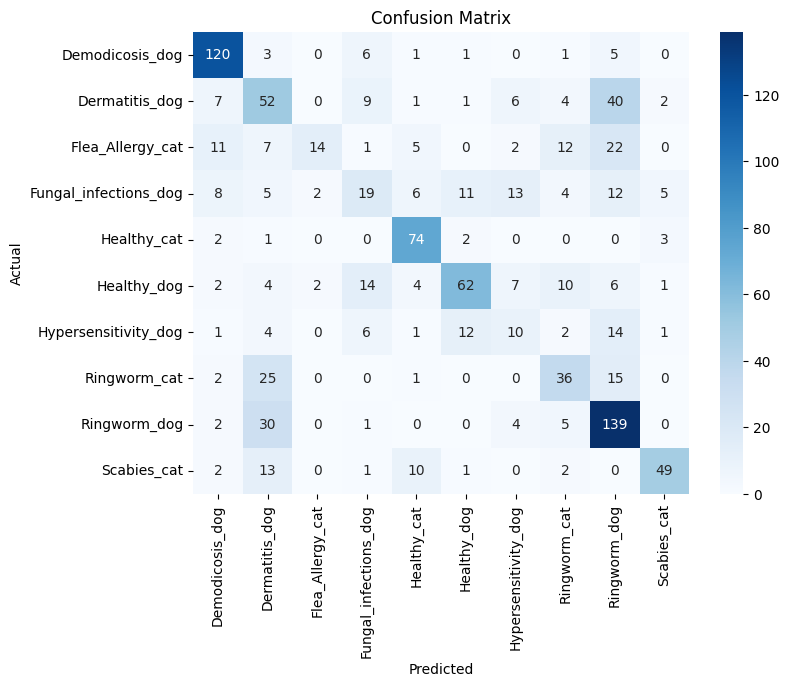

In [16]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [17]:
import pandas as pd
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=[f"Actual: {name}" for name in class_names],
    columns=[f"Pred: {name}" for name in class_names]
)

print("\nConfusion Matrix (Labeled):\n")
print(cm_df)


Confusion Matrix (Labeled):

                               Pred: Demodicosis_dog  Pred: Dermatitis_dog  \
Actual: Demodicosis_dog                          120                     3   
Actual: Dermatitis_dog                             7                    52   
Actual: Flea_Allergy_cat                          11                     7   
Actual: Fungal_infections_dog                      8                     5   
Actual: Healthy_cat                                2                     1   
Actual: Healthy_dog                                2                     4   
Actual: Hypersensitivity_dog                       1                     4   
Actual: Ringworm_cat                               2                    25   
Actual: Ringworm_dog                               2                    30   
Actual: Scabies_cat                                2                    13   

                               Pred: Flea_Allergy_cat  \
Actual: Demodicosis_dog                             0 


MODEL PERFORMANCE METRICS
Accuracy:  0.5744 (57.44%)
Precision: 0.5818
Recall:    0.5744
F1-Score:  0.5572


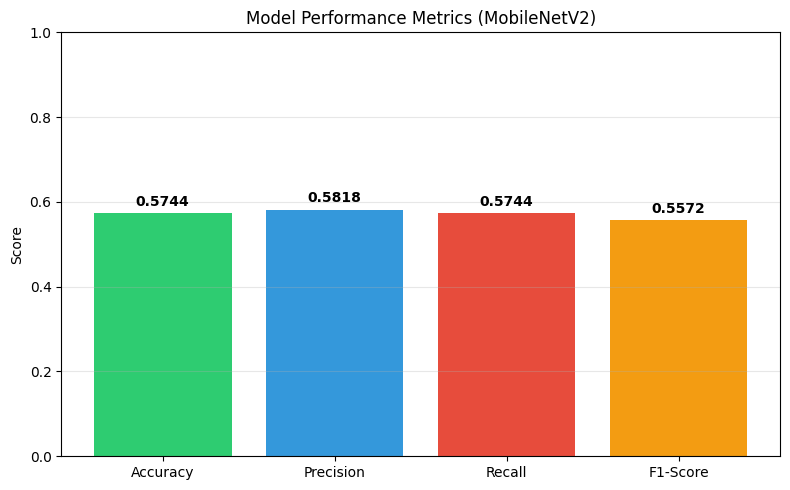


CLASSIFICATION REPORT:
                       precision    recall  f1-score   support

      Demodicosis_dog       0.76      0.88      0.82       137
       Dermatitis_dog       0.36      0.43      0.39       122
     Flea_Allergy_cat       0.78      0.19      0.30        74
Fungal_infections_dog       0.33      0.22      0.27        85
          Healthy_cat       0.72      0.90      0.80        82
          Healthy_dog       0.69      0.55      0.61       112
 Hypersensitivity_dog       0.24      0.20      0.22        51
         Ringworm_cat       0.47      0.46      0.46        79
         Ringworm_dog       0.55      0.77      0.64       181
          Scabies_cat       0.80      0.63      0.71        78

             accuracy                           0.57      1001
            macro avg       0.57      0.52      0.52      1001
         weighted avg       0.58      0.57      0.56      1001



In [18]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

# Display metrics
print("\n" + "="*60)
print("MODEL PERFORMANCE METRICS")
print("="*60)
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print("="*60)

# Bar chart visualization
import matplotlib.pyplot as plt

metrics_dict = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1
}

plt.figure(figsize=(8, 5))
bars = plt.bar(metrics_dict.keys(), metrics_dict.values(), 
               color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12'])
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Model Performance Metrics (MobileNetV2)')
plt.grid(axis='y', alpha=0.3)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Detailed classification report
print("\nCLASSIFICATION REPORT:")
print("="*65)
print(classification_report(y_true, y_pred, target_names=class_names))
print("="*65)